# Semana 6: Fundamentos de Ingeniería de Datos
## Práctica: Construcción de un Pipeline ETL y Modelado Dimensional (Esquema Estrella)

**Materia:** Optativa 3 - Ciencia de Datos  
**Estudiante:** Samir Mares Benvenuto  
**Objetivo:** Construir un pipeline ETL (*Extract, Transform, Load*) completo en Python que extraiga transacciones comerciales, cree features analíticas, aplique modelado dimensional en esquema estrella y cargue los datos a SQLite para consultas analíticas (OLAP).

---
### Arquitectura del Pipeline:
1. **EXTRACT:** Lectura de archivo CSV con datos crudos de transacciones.
2. **TRANSFORM:** Cálculo de ingreso total por venta ($total = precio \times cantidad$) y separación dimensional en `dim_categoria` (dimensión) y `fact_ventas` (hechos).
3. **LOAD:** Persistencia en SQLite (`almacen.db`).
4. **ANALYSIS:** Consultas analíticas SQL con agregaciones y visualización gráfica.


In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.precision', 2)
print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 1. Fase EXTRACT (Extracción)
En esta fase extraemos los datos crudos desde nuestra fuente de almacenamiento plano (`ventas.csv`).


In [2]:
csv_file = "ventas.csv"
df_raw = pd.read_csv(csv_file)

print(f"Filas extraídas: {len(df_raw)}")
print(f"Columnas: {list(df_raw.columns)}")
display(df_raw.head())


Filas extraídas: 15
Columnas: ['producto', 'categoria', 'precio', 'cantidad']


,producto,categoria,precio,cantidad
0,Cafe Espresso,Bebidas Calientes,35.0,3
1,Capuchino Vainilla,Bebidas Calientes,48.0,2
2,Te Verde Matcha,Bebidas Calientes,52.0,1
3,Croissant de Mantequilla,Panaderia,28.0,4
4,Muffin de Arandanos,Panaderia,32.0,2


## 2. Fase TRANSFORM (Transformación y Modelado Dimensional)
En esta fase realizamos:
1. **Feature Engineering:** Creación de la métrica aditiva `total = precio * cantidad`.
2. **Modelado Dimensional (Star Schema):**
   - **`dim_categoria`**: Dimensión desnormalizada con clave subrogada `cat_id`.
   - **`fact_ventas`**: Tabla de hechos central con `venta_id`, `cat_id` (FK), métricas numéricas y atributos de la transacción.


In [3]:
df_transformed = df_raw.copy()

# 2.1 Feature Engineering: Ingreso total
df_transformed["total"] = df_transformed["precio"] * df_transformed["cantidad"]

# 2.2 Dimensión de Categoría (dim_categoria)
categorias = sorted(df_transformed["categoria"].unique())
dim_categoria = pd.DataFrame({
    "cat_id": range(1, len(categorias) + 1),
    "categoria": categorias
})

# 2.3 Tabla de Hechos (fact_ventas)
fact = df_transformed.merge(dim_categoria, on="categoria")
fact["venta_id"] = range(1, len(fact) + 1)
fact_ventas = fact[["venta_id", "producto", "cat_id", "precio", "cantidad", "total"]]

print("Dimensión: dim_categoria")
display(dim_categoria)

print("\nTabla de Hechos: fact_ventas (Primeros registros)")
display(fact_ventas.head())


Dimensión: dim_categoria


,cat_id,categoria
0,1,Alimentos Preparados
1,2,Bebidas Calientes
2,3,Bebidas Frias
3,4,Panaderia
4,5,Snacks y Dulces



Tabla de Hechos: fact_ventas (Primeros registros)


,venta_id,producto,cat_id,precio,cantidad,total
0,1,Cafe Espresso,2,35.0,3,105.0
1,2,Capuchino Vainilla,2,48.0,2,96.0
2,3,Te Verde Matcha,2,52.0,1,52.0
3,4,Croissant de Mantequilla,4,28.0,4,112.0
4,5,Muffin de Arandanos,4,32.0,2,64.0


## 3. Fase LOAD (Carga en SQLite)
Cargamos las tablas generadas en una base de datos relacional SQLite (`almacen.db`).


In [4]:
db_name = "almacen.db"
conn = sqlite3.connect(db_name)

# Guardar tablas en SQLite
dim_categoria.to_sql("dim_categoria", conn, if_exists="replace", index=False)
fact_ventas.to_sql("fact_ventas", conn, if_exists="replace", index=False)

print(f"Tablas cargadas exitosamente en {db_name}:")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print([t[0] for t in cursor.fetchall()])


Tablas cargadas exitosamente en almacen.db:
['dim_categoria', 'fact_ventas']


## 4. Consulta Analítica OLAP (Esquema Estrella en Acción)
Ejecutamos una consulta SQL con `JOIN` entre la tabla de hechos y la dimensión para resumir el rendimiento por categoría.


In [5]:
query = """
SELECT 
    d.categoria, 
    COUNT(f.venta_id) AS num_ventas,
    SUM(f.cantidad) AS unidades_vendidas,
    ROUND(AVG(f.precio), 2) AS ticket_promedio,
    ROUND(SUM(f.total), 2) AS ingresos_totales
FROM fact_ventas f 
JOIN dim_categoria d ON f.cat_id = d.cat_id 
GROUP BY d.categoria 
ORDER BY ingresos_totales DESC;
"""

reporte_df = pd.read_sql(query, conn)
display(reporte_df)


,categoria,num_ventas,unidades_vendidas,ticket_promedio,ingresos_totales
0,Alimentos Preparados,3,6,78.33,466.0
1,Bebidas Frias,3,7,51.67,352.0
2,Snacks y Dulces,3,12,26.00,304.0
3,Bebidas Calientes,3,6,45.00,253.0
4,Panaderia,3,7,35.00,221.0


## 5. Visualización Directiva de los Datos
Generamos un gráfico comparativo de ingresos y volumen por categoría para soportar la toma de decisiones.


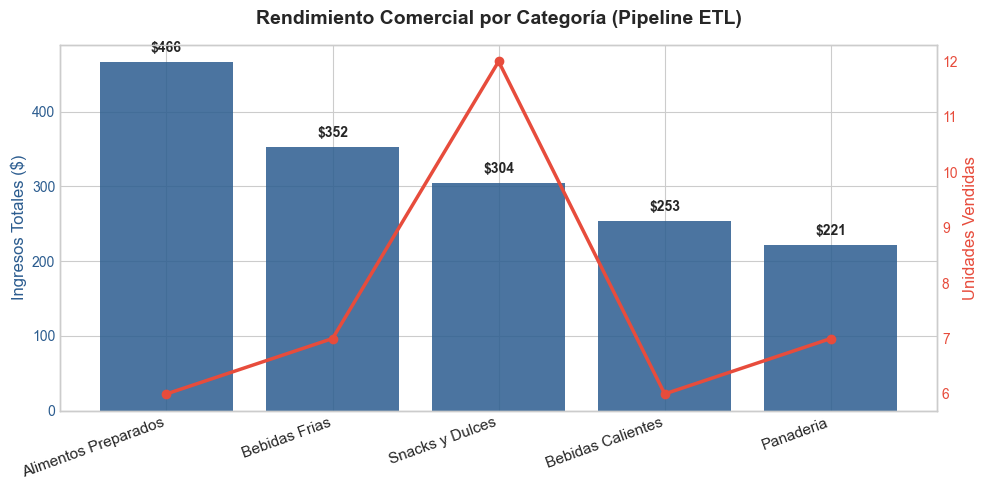

Conexión a SQLite cerrada exitosamente.


In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfico de barras para ingresos totales
bars = ax1.bar(reporte_df["categoria"], reporte_df["ingresos_totales"], color="#2b5c8f", alpha=0.85, label="Ingresos Totales ($)")
ax1.set_ylabel("Ingresos Totales ($)", color="#2b5c8f", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#2b5c8f")
ax1.set_title("Rendimiento Comercial por Categoría (Pipeline ETL)", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=20, ha="right", fontsize=11)

# Eje secundario para unidades vendidas
ax2 = ax1.twinx()
line = ax2.plot(reporte_df["categoria"], reporte_df["unidades_vendidas"], color="#e74c3c", marker="o", linewidth=2.5, label="Unidades Vendidas")
ax2.set_ylabel("Unidades Vendidas", color="#e74c3c", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#e74c3c")
ax2.grid(False)

# Etiquetas en las barras
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 10, f"${yval:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("ingresos_por_categoria.png", dpi=200)
plt.show()

# Cierre de conexión
conn.close()
print("Conexión a SQLite cerrada exitosamente.")
